In [70]:
"""Create neuron-type donut charts for the literature-review Figure 1C panel."""

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [71]:
# Literature-derived autapse percentages grouped by layer/region, E/I class,
# and neuron subtype. TAG selects the subset to export from this notebook.
TAG = 'CORTEX'

cols = ["Layer", "E/I", "neuron-type", "%"]
data = np.array([['Layer 5', 'Inhibitory', 'FS', 85],
                ['Layer 5', 'Inhibitory', 'non-FS', 0],
                ['Layer 5', 'Inhibitory', 'FS', 27.9],
                ['Layer 5', 'Inhibitory', 'FS', 80],
                ['Layer 5', 'Inhibitory', 'FS', 74],
                ['Layer 2/3', 'Inhibitory', 'FS', 69.4],
                ['Layer 2/3', 'Inhibitory', 'non-FS', 7.1],
                ['Layer 5', 'Inhibitory', 'FS', 90],
                ['CA1-3', 'Inhibitory', 'basket', 100.],
                ['CA1-3', 'Inhibitory', 'bistratified', 65.],
                ['CA1-3', 'Inhibitory', 'axo-axonic', 0.],
                ['CA1-3', 'Inhibitory', 'basket', 100.],
                ['CA1-3', 'Inhibitory', 'bistratified', 100.],
                ['Striatum', 'Inhibitory', 'PV', 50.],
                ['Striatum', 'Inhibitory', 'SPN', 0.]])

if TAG == 'CORTEX':
    data1 = pd.DataFrame(data = data, columns = cols)

# Convert percentages from object strings to numeric values before aggregation.
data1['%'] = pd.to_numeric(data1['%'])

print(data1.head())


     Layer         E/I neuron-type     %
0  Layer 5  Inhibitory          FS  85.0
1  Layer 5  Inhibitory      non-FS   0.0
2  Layer 5  Inhibitory          FS  27.9
3  Layer 5  Inhibitory          FS  80.0
4  Layer 5  Inhibitory          FS  74.0


"\n# 4. Global title and layout configuration\nplt.suptitle('Proportion ($\\%$) of Neurons Forming Autapses', fontsize=15, y=0.98)\nplt.tight_layout()\n#plt.savefig(f'plots//neuron_type_pie_charts_{TAG}.png', dpi=300, bbox_inches='tight')\nplt.show()\n"

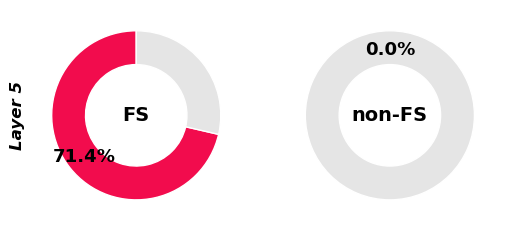

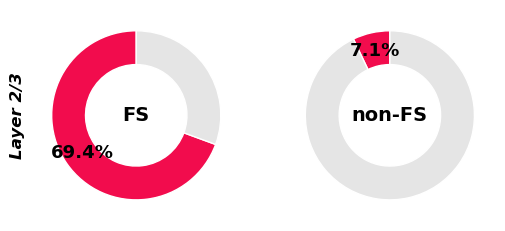

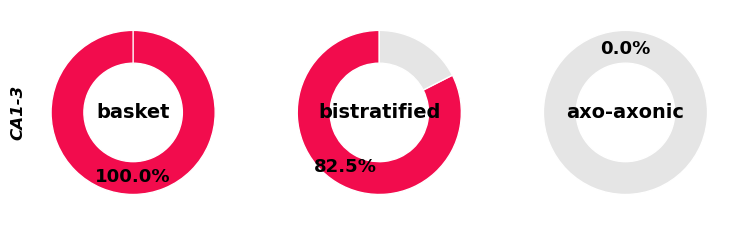

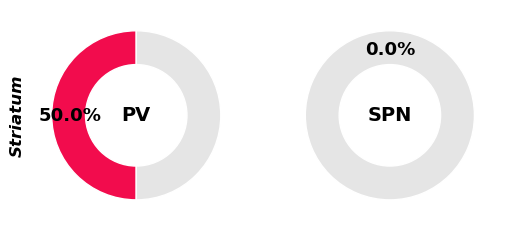

In [72]:
# Average repeated literature measurements for the same layer/type combination.
df_mean = data1.groupby(['Layer', 'neuron-type', 'E/I'])['%'].mean().reset_index()

# Preserve the order in which layers appear in the source table so exported rows
# match the review narrative.
layers = data1['Layer'].unique()
neuron_order = ['FS', 'non-FS', 'basket', 'bistratified', 'axo-axonic', 'PV', 'SPN']

custom_palette = {'Excitatory': '#2678fc', 'Inhibitory': '#f20c4d'}
remainder_color = '#e5e5e5' # Light gray for neurons without autapses

# Export one row of donut charts per layer/region.
for row, layer in enumerate(layers):
    sub_df = data1[data1['Layer'] == layer]

    # Only draw neuron types that are represented in the current layer/region.
    neuron_order = sub_df['neuron-type'].unique()
    fig, axes = plt.subplots(1, len(neuron_order), figsize=(3*len(neuron_order), 4))

    for col, neuron in enumerate(neuron_order):
        ax = axes[col]
        
        # Look up the averaged autapse percentage for this layer/type pair.
        match = df_mean[(df_mean['Layer'] == layer) & (df_mean['neuron-type'] == neuron)]
        
        if not match.empty:
            with_autapses = match['%'].values[0]
            ei_status = match['E/I'].values[0]
            primary_color = custom_palette[ei_status]
        else:
            with_autapses = 0.0
            primary_color = remainder_color
            
        without_autapses = 100.0 - with_autapses
        
        # Donut slices show autapse-forming cells versus the remaining population.
        slices = [with_autapses, without_autapses]
        colors = [primary_color, remainder_color]
        
        wedges, texts, autotexts = ax.pie(
            slices, 
            startangle=90, 
            colors=colors,
            autopct=lambda p: f'{p:.1f}%',
            pctdistance=0.78,
            wedgeprops=dict(width=0.4, edgecolor='w')
        )

        # Label the neuron class in the center of each donut.
        ax.text(
            0, 0, 
            f'{neuron}', 
            ha='center', 
            va='center', 
            fontsize=14, 
            fontweight='bold', 
            color='black'
        )
        
        # Keep only the autapse percentage label; the gray remainder is implicit.
        if len(autotexts) > 1:
            autotexts[1].set_text('')
            
        autotexts[0].set_fontsize(13)
        autotexts[0].set_weight('bold')
        autotexts[0].set_color('black')

    axes[0].set_ylabel(f'{layer}',fontsize=12, fontstyle = 'italic', fontweight = 'bold')

    safe_layer = layer.replace(' ', '_').replace('/', '-')
    plt.savefig(f'plots//neuron_type_pie_charts_{safe_layer}.svg', dpi=300, bbox_inches='tight')

"""
# Optional combined-title layout retained for quick exploratory renders.
plt.suptitle('Proportion ($\\%$) of Neurons Forming Autapses', fontsize=15, y=0.98)
plt.tight_layout()
#plt.savefig(f'plots//neuron_type_pie_charts_{TAG}.png', dpi=300, bbox_inches='tight')
plt.show()
"""
